In [12]:
# Display tools
from IPython.display import HTML, display  # For HTML rendering in notebooks
import os 
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
import tensorflow as tf

In [14]:
import matplotlib.pyplot as plt

def plot_score(hist):
    fig, ax = plt.subplots(5, 1, figsize=(10, 20))  # Corrected 'subplot' to 'subplots'
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'precision', 'recall', 'AUC', 'loss']):
        ax[i].plot(hist.history[met])
        ax[i].plot(hist.history['val_' + met])
        ax[i].set_title(f'Model {met}')
        ax[i].set_xlabel('Epochs')
        ax[i].set_ylabel(met)
        ax[i].legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.show()


In [15]:
import os
import numpy as np

# Set directory where .npy files are stored
npy_dir = 'npy_data'

# Load preprocessed datasets
train_X_rgb = np.load(os.path.join(npy_dir, 'train_X_rgb.npy'))
train_Y     = np.load(os.path.join(npy_dir, 'train_Y.npy'))
test_X_rgb  = np.load(os.path.join(npy_dir, 'test_X_rgb.npy'))
test_Y      = np.load(os.path.join(npy_dir, 'test_Y.npy'))

In [16]:
# If not already defined earlier, calculate class weights again:
import pandas as pd

labels = pd.read_csv(r"C:\Users\samya\PyCharmProject\Pneumonia-Detection_dataset\data\stage_2_train_labels.csv")
count_normal = (labels['Target'] == 0).sum()
count_pneumonia = (labels['Target'] == 1).sum()
train_count = len(train_X_rgb)

classweight = {
    0: (1 / count_normal) * (train_count / 2.0),
    1: (1 / count_pneumonia) * (train_count / 2.0)
}

In [17]:
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras import Model


In [18]:
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='AUC'),
    tf.keras.metrics.TruePositives(name='tp'),
    tf.keras.metrics.TrueNegatives(name='tn'),
    tf.keras.metrics.FalsePositives(name='fp'),
    tf.keras.metrics.FalseNegatives(name='fn'),
    tf.keras.metrics.SpecificityAtSensitivity(0.9, name='specificity_at_sens_90'),
    tf.keras.metrics.SensitivityAtSpecificity(0.9, name='sensitivity_at_spec_90'),
]

In [19]:
import tensorflow as tf

# Flexible Exponential Decay Function
def get_exponential_decay_fn(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    """
    Returns a learning rate function using exponential decay.
    """
    return lambda epoch: lr_initial * decay_rate ** (epoch / decay_steps)

# Returns a LearningRateScheduler callback with decay configuration
def get_lr_scheduler_cb(lr_initial=0.01, decay_steps=20, decay_rate=0.1):
    return tf.keras.callbacks.LearningRateScheduler(
        schedule=get_exponential_decay_fn(lr_initial, decay_steps, decay_rate),
        verbose=1
    )

# Returns a ModelCheckpoint callback that saves to a unique file
def get_model_checkpoint_cb(model_name):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{model_name}.h5",
        save_best_only=True,
        monitor="val_loss",
        mode="min",
        verbose=1
    )

# Shared EarlyStopping callback
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

In [21]:
import tensorflow as tf

def Cust_Cnn_model():
    model = tf.keras.Sequential([

        # First convolutional block: extracts low-level features (edges, textures)
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding='valid',
                               activation='relu', input_shape=(64, 64, 3)),
        tf.keras.layers.MaxPool2D(pool_size=(2, 2)),  # Reduces spatial size by 2x

        # Second convolutional block: detects more complex patterns
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1),
                               padding='valid', activation='relu'),
        tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
        tf.keras.layers.Dropout(0.3),  # Regularization to reduce overfitting

        # Deeper convolutional layers with increased filters
        tf.keras.layers.Conv2D(64, 3, activation='relu', padding='valid'),
        tf.keras.layers.Conv2D(128, 3, activation='relu', padding='valid'),
        tf.keras.layers.BatchNormalization(),  # Normalizes activations for stability
        tf.keras.layers.MaxPool2D(),           # Further downsamples the feature maps
        tf.keras.layers.Dropout(0.4),          # Additional regularization

        # Flatten feature maps into 1D vector before entering dense layers
        tf.keras.layers.Flatten(),

        # First fully connected layer with high capacity
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),  # Helps speed up and stabilize training
        tf.keras.layers.Dropout(0.5),          # Strong regularization for deep layers

        # Second dense layer
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),

        # Output layer for binary classification
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    return model

In [22]:
print("Model is being built...")
model_cnn = Cust_Cnn_model()
model_cnn.summary()

Model is being built...


c:\Users\samya\PyCharmProject\Pneumonia-Detection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,810,273 (6.91 MB)

 Trainable params: 1,808,737 (6.90 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [23]:

# Compile the model
model_cnn.compile(optimizer='adam',loss='binary_crossentropy', metrics=METRICS)
checkpoint_cb = get_model_checkpoint_cb("cnn_model")  # Ensure it doesn't overwrite fcnn_model.h5


In [21]:
checkpoint_cb = get_model_checkpoint_cb("mn_cnn_model")
lr_scheduler_cb = get_lr_scheduler_cb()

In [ ]:
# Train the CNN model with validation split and callbacks, no data shuffling
history_mn = model_mn.fit(
    x=train_X_rgb,
    y=train_Y,
    epochs=50,
    batch_size=128,
    validation_split=0.15,
    class_weight=classweight,
    callbacks=[
        checkpoint_cb,         # Saves best model based on val_loss
        early_stopping_cb,     # Stops early if no val_loss improvement
        lr_scheduler_cb        # Adjusts learning rate over epochs
    ],
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - AUC: 0.9082 - accuracy: 0.8168 - fn: 536.4832 - fp: 1337.1798 - loss: 0.3627 - precision: 0.7953 - recall: 0.8946 - sensitivity_at_spec_90: 0.7532 - specificity_at_sens_90: 0.7211 - tn: 3891.6011 - tp: 5690.1572
Epoch 1: val_loss improved from inf to 1.59594, saving model to mn_cnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 75s 377ms/step - AUC: 0.9084 - accuracy: 0.8170 - fn: 538.7933 - fp: 1343.4246 - loss: 0.3623 - precision: 0.7955 - recall: 0.8947 - sensitivity_at_spec_90: 0.7536 - specificity_at_sens_90: 0.7217 - tn: 3914.0837 - tp: 5721.8325 - val_AUC: 0.8618 - val_accuracy: 0.5681 - val_fn: 0.0000e+00 - val_fp: 1729.0000 - val_loss: 1.5959 - val_precision: 0.5601 - val_recall: 1.0000 - val_sensitivity_at_spec_90: 0.0000e+00 - val_specificity_at_sens_90: 0.6532 - val_tn: 73.0000 - val_tp: 2201.0000 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.008912509381337455.
Epoch 2/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - AUC: 0.9594 - accuracy: 0.8858 - fn: 337.7022 - fp: 960.0674 - loss: 0.2419 - precision: 0.8586 - recall: 0.9461 - sensitivity_at_spec_90: 0.8909 - specificity_at_sens_90: 0.8881 - tn: 4291.3989 - tp: 5866.2529
Epoch 2: val_loss improved from 1.59594 to 0.34268, saving model to mn_cnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 90s 505ms/step - AUC: 0.9594 - accuracy: 0.8858 - fn: 339.6536 - fp: 965.2849 - loss: 0.2419 - precision: 0.8586 - recall: 0.9461 - sensitivity_at_spec_90: 0.8909 - specificity_at_sens_90: 0.8881 - tn: 4314.7822 - tp: 5898.4136 - val_AUC: 0.9601 - val_accuracy: 0.8536 - val_fn: 45.0000 - val_fp: 541.0000 - val_loss: 0.3427 - val_precision: 0.7994 - val_recall: 0.9796 - val_sensitivity_at_spec_90: 0.8746 - val_specificity_at_sens_90: 0.8790 - val_tn: 1261.0000 - val_tp: 2156.0000 - learning_rate: 0.0089

Epoch 3: LearningRateScheduler setting learning rate to 0.007943282347242816.
Epoch 3/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - AUC: 0.9621 - accuracy: 0.8873 - fn: 331.2303 - fp: 942.7079 - loss: 0.2349 - precision: 0.8583 - recall: 0.9487 - sensitivity_at_spec_90: 0.8931 - specificity_at_sens_90: 0.8920 - tn: 4302.9717 - tp: 5878.5112
Epoch 3: val_loss improved from 0.34268 to 0.28918, saving model to mn_cnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 101s 566ms/step - AUC: 0.9621 - accuracy: 0.8873 - fn: 333.0782 - fp: 947.6648 - loss: 0.2349 - precision: 0.8583 - recall: 0.9486 - sensitivity_at_spec_90: 0.8932 - specificity_at_sens_90: 0.8920 - tn: 4326.6479 - tp: 5910.7432 - val_AUC: 0.9826 - val_accuracy: 0.8703 - val_fn: 29.0000 - val_fp: 490.0000 - val_loss: 0.2892 - val_precision: 0.8159 - val_recall: 0.9868 - val_sensitivity_at_spec_90: 0.9609 - val_specificity_at_sens_90: 0.9634 - val_tn: 1312.0000 - val_tp: 2172.0000 - learning_rate: 0.0079

Epoch 4: LearningRateScheduler setting learning rate to 0.0070794578438413795.
Epoch 4/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - AUC: 0.9665 - accuracy: 0.8977 - fn: 315.5337 - fp: 846.9663 - loss: 0.2215 - precision: 0.8731 - recall: 0.9508 - sensitivity_at_spec_90: 0.9140 - specificity_at_sens_90: 0.9159 - tn: 4367.0396 - tp: 5925.8818
Epoch 4: val_loss improved from 0.28918 to 0.17060, saving model to mn_cnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 84s 475ms/step - AUC: 0.9665 - accuracy: 0.8977 - fn: 317.2291 - fp: 851.6760 - loss: 0.2215 - precision: 0.8731 - recall: 0.9508 - sensitivity_at_spec_90: 0.9140 - specificity_at_sens_90: 0.9159 - tn: 4391.1396 - tp: 5958.0894 - val_AUC: 0.9854 - val_accuracy: 0.9410 - val_fn: 74.0000 - val_fp: 162.0000 - val_loss: 0.1706 - val_precision: 0.9292 - val_recall: 0.9664 - val_sensitivity_at_spec_90: 0.9700 - val_specificity_at_sens_90: 0.9734 - val_tn: 1640.0000 - val_tp: 2127.0000 - learning_rate: 0.0071

Epoch 5: LearningRateScheduler setting learning rate to 0.006309573444801933.
Epoch 5/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - AUC: 0.9686 - accuracy: 0.9037 - fn: 301.0112 - fp: 802.9663 - loss: 0.2124 - precision: 0.8800 - recall: 0.9517 - sensitivity_at_spec_90: 0.9251 - specificity_at_sens_90: 0.9221 - tn: 4450.0898 - tp: 5901.3540
Epoch 5: val_loss improved from 0.17060 to 0.16673, saving model to mn_cnn_model.h5


...

178/178 ━━━━━━━━━━━━━━━━━━━━ 86s 485ms/step - AUC: 0.9723 - accuracy: 0.9099 - fn: 272.7263 - fp: 770.4134 - loss: 0.1977 - precision: 0.8868 - recall: 0.9574 - sensitivity_at_spec_90: 0.9324 - specificity_at_sens_90: 0.9294 - tn: 4471.7373 - tp: 6003.2568 - val_AUC: 0.9867 - val_accuracy: 0.9430 - val_fn: 81.0000 - val_fp: 147.0000 - val_loss: 0.1533 - val_precision: 0.9352 - val_recall: 0.9632 - val_sensitivity_at_spec_90: 0.9691 - val_specificity_at_sens_90: 0.9822 - val_tn: 1655.0000 - val_tp: 2120.0000 - learning_rate: 0.0045

Epoch 9: LearningRateScheduler setting learning rate to 0.0039810717055349725.
Epoch 9/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - AUC: 0.9722 - accuracy: 0.9139 - fn: 270.5562 - fp: 726.8203 - loss: 0.2003 - precision: 0.8928 - recall: 0.9565 - sensitivity_at_spec_90: 0.9309 - specificity_at_sens_90: 0.9339 - tn: 4503.8428 - tp: 5954.2021
Epoch 9: val_loss improved from 0.15330 to 0.14599, saving model to mn_cnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 83s 466ms/step - AUC: 0.9722 - accuracy: 0.9139 - fn: 272.0000 - fp: 730.7766 - loss: 0.2003 - precision: 0.8928 - recall: 0.9565 - sensitivity_at_spec_90: 0.9309 - specificity_at_sens_90: 0.9339 - tn: 4528.6035 - tp: 5986.7544 - val_AUC: 0.9869 - val_accuracy: 0.9490 - val_fn: 90.0000 - val_fp: 114.0000 - val_loss: 0.1460 - val_precision: 0.9488 - val_recall: 0.9591 - val_sensitivity_at_spec_90: 0.9687 - val_specificity_at_sens_90: 0.9795 - val_tn: 1688.0000 - val_tp: 2111.0000 - learning_rate: 0.0040

Epoch 10: LearningRateScheduler setting learning rate to 0.003548133892335755.
Epoch 10/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - AUC: 0.9764 - accuracy: 0.9174 - fn: 280.5899 - fp: 683.6292 - loss: 0.1862 - precision: 0.9004 - recall: 0.9530 - sensitivity_at_spec_90: 0.9399 - specificity_at_sens_90: 0.9433 - tn: 4568.4214 - tp: 5922.7808
Epoch 10: val_loss did not improve from 0.14599
178/178 ━━━━━━━━━━━━━━━━━━━━ 82s 461ms/step - AUC: 0.9764 - accurac

178/178 ━━━━━━━━━━━━━━━━━━━━ 80s 447ms/step - AUC: 0.9756 - accuracy: 0.9185 - fn: 263.7263 - fp: 674.6871 - loss: 0.1865 - precision: 0.8984 - recall: 0.9578 - sensitivity_at_spec_90: 0.9435 - specificity_at_sens_90: 0.9443 - tn: 4592.3408 - tp: 5987.3799 - val_AUC: 0.9881 - val_accuracy: 0.9460 - val_fn: 77.0000 - val_fp: 139.0000 - val_loss: 0.1435 - val_precision: 0.9386 - val_recall: 0.9650 - val_sensitivity_at_spec_90: 0.9750 - val_specificity_at_sens_90: 0.9822 - val_tn: 1663.0000 - val_tp: 2124.0000 - learning_rate: 0.0032

Epoch 12: LearningRateScheduler setting learning rate to 0.002818382931264454.
Epoch 12/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - AUC: 0.9768 - accuracy: 0.9174 - fn: 262.6854 - fp: 682.7360 - loss: 0.1832 - precision: 0.8973 - recall: 0.9565 - sensitivity_at_spec_90: 0.9387 - specificity_at_sens_90: 0.9436 - tn: 4580.2080 - tp: 5929.7920
Epoch 12: val_loss did not improve from 0.14351
178/178 ━━━━━━━━━━━━━━━━━━━━ 79s 446ms/step - AUC: 0.9767 - accurac

178/178 ━━━━━━━━━━━━━━━━━━━━ 70s 392ms/step - AUC: 0.9788 - accuracy: 0.9197 - fn: 239.3352 - fp: 667.0558 - loss: 0.1747 - precision: 0.8965 - recall: 0.9619 - sensitivity_at_spec_90: 0.9478 - specificity_at_sens_90: 0.9499 - tn: 4613.5752 - tp: 5998.1675 - val_AUC: 0.9890 - val_accuracy: 0.9490 - val_fn: 61.0000 - val_fp: 143.0000 - val_loss: 0.1401 - val_precision: 0.9374 - val_recall: 0.9723 - val_sensitivity_at_spec_90: 0.9777 - val_specificity_at_sens_90: 0.9861 - val_tn: 1659.0000 - val_tp: 2140.0000 - learning_rate: 0.0018

Epoch 17: LearningRateScheduler setting learning rate to 0.0015848931924611134.
Epoch 17/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - AUC: 0.9790 - accuracy: 0.9230 - fn: 241.5955 - fp: 648.6854 - loss: 0.1731 - precision: 0.9028 - recall: 0.9605 - sensitivity_at_spec_90: 0.9500 - specificity_at_sens_90: 0.9527 - tn: 4576.7080 - tp: 5988.4326
Epoch 17: val_loss improved from 0.14011 to 0.13555, saving model to mn_cnn_model.h5


178/178 ━━━━━━━━━━━━━━━━━━━━ 76s 426ms/step - AUC: 0.9790 - accuracy: 0.9229 - fn: 242.8771 - fp: 652.3855 - loss: 0.1731 - precision: 0.9028 - recall: 0.9605 - sensitivity_at_spec_90: 0.9500 - specificity_at_sens_90: 0.9527 - tn: 4601.7544 - tp: 6021.1172 - val_AUC: 0.9897 - val_accuracy: 0.9505 - val_fn: 61.0000 - val_fp: 137.0000 - val_loss: 0.1356 - val_precision: 0.9398 - val_recall: 0.9723 - val_sensitivity_at_spec_90: 0.9786 - val_specificity_at_sens_90: 0.9872 - val_tn: 1665.0000 - val_tp: 2140.0000 - learning_rate: 0.0016

Epoch 18: LearningRateScheduler setting learning rate to 0.0014125375446227546.
Epoch 18/50
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - AUC: 0.9789 - accuracy: 0.9222 - fn: 247.2865 - fp: 636.6124 - loss: 0.1724 - precision: 0.9038 - recall: 0.9585 - sensitivity_at_spec_90: 0.9485 - specificity_at_sens_90: 0.9520 - tn: 4577.0562 - tp: 5994.4663
Epoch 18: val_loss did not improve from 0.13555
178/178 ━━━━━━━━━━━━━━━━━━━━ 71s 400ms/step - AUC: 0.9789 - accura

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - AUC: 0.9971 - accuracy: 0.9937 - fn: 4.2842 - fp: 4.1053 - loss: 0.0349 - precision: 0.9954 - recall: 0.9929 - sensitivity_at_spec_90: 0.9967 - specificity_at_sens_90: 0.9981 - tn: 712.9053 - tp: 814.2000

Evaluation Results:
                 AUC: 0.9977
            accuracy: 0.9937
                  fn: 10.0000
                  fp: 9.0000
                loss: 0.0285
           precision: 0.9944
              recall: 0.9938
sensitivity_at_spec_90: 0.9981
specificity_at_sens_90: 0.9978
                  tn: 1373.0000
                  tp: 1608.0000


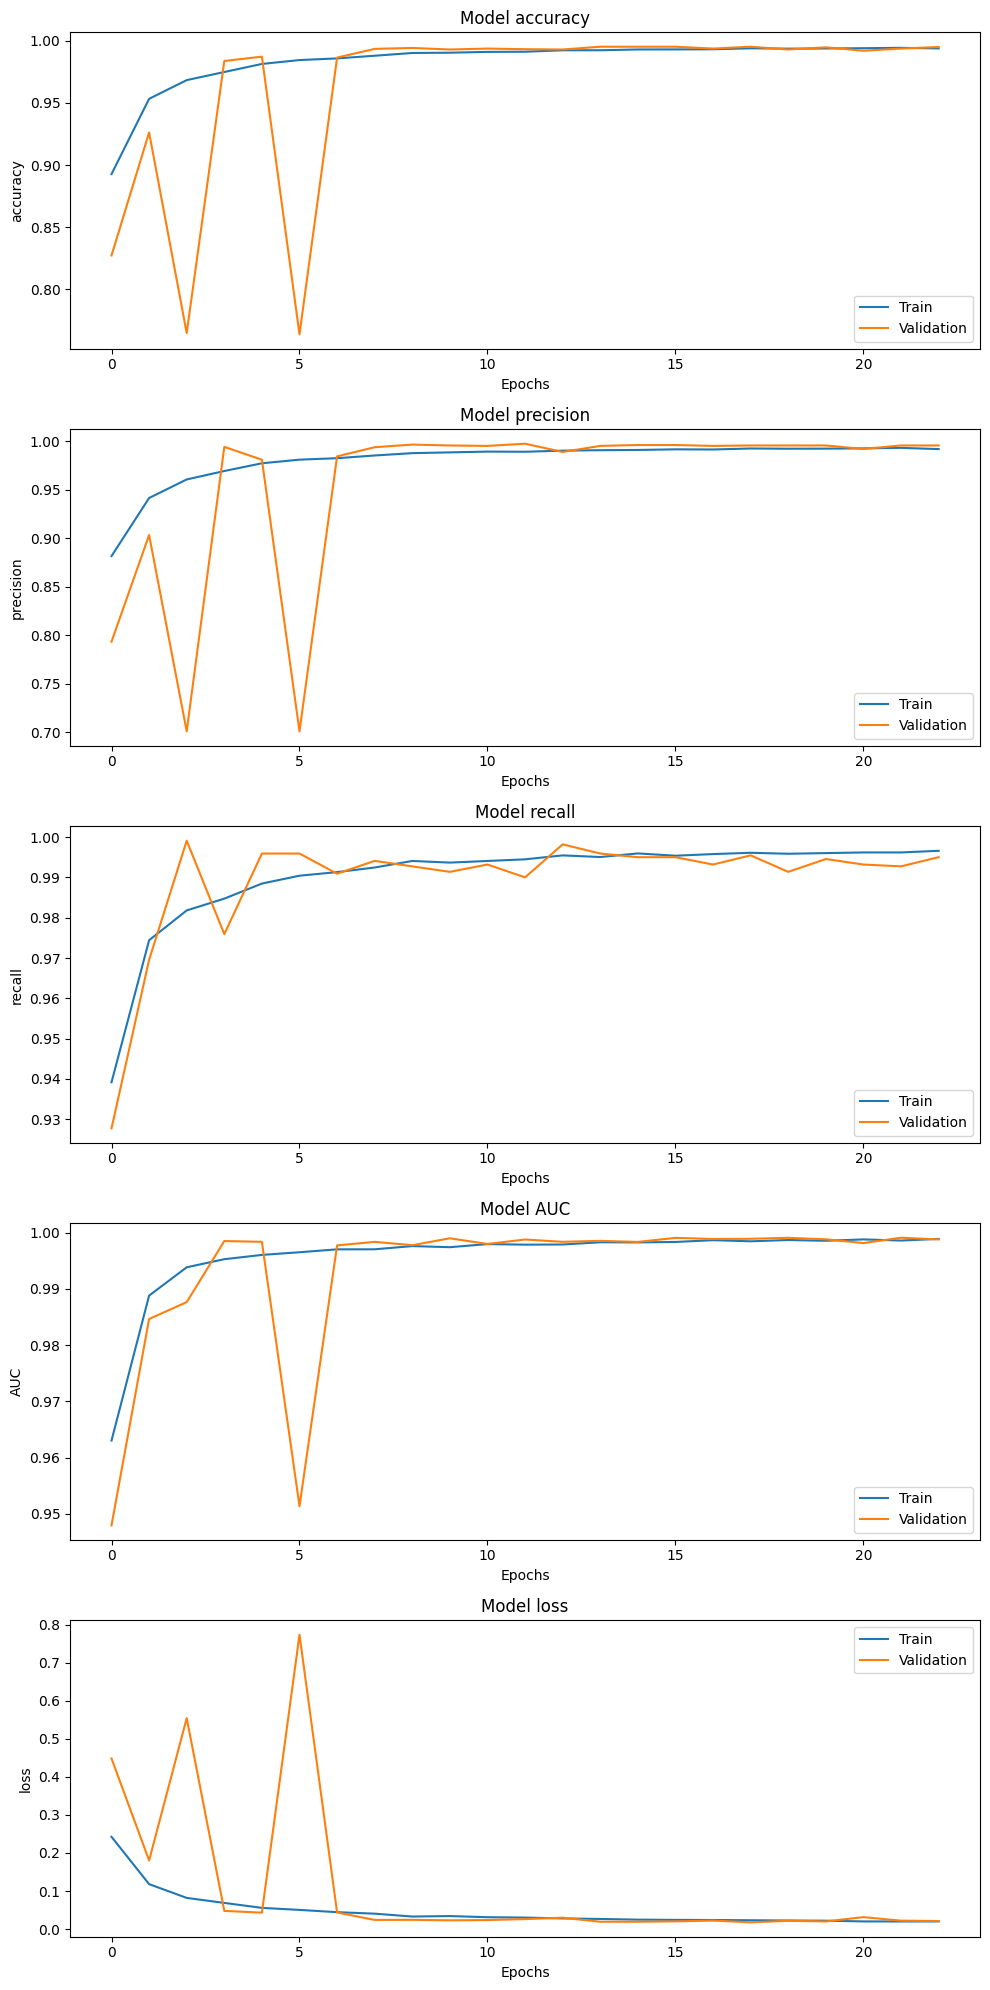

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Confusion Matrix:
[[1270  112]
 [  59 1559]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9556    0.9190    0.9369      1382
           1     0.9330    0.9635    0.9480      1618

    accuracy                         0.9430      3000
   macro avg     0.9443    0.9412    0.9425      3000
weighted avg     0.9434    0.9430    0.9429      3000



In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate the trained model on the test dataset and return results as a dictionary
results = model_cnn.evaluate(test_X_rgb, test_Y, return_dict=True)

# Display evaluation metrics in a readable format
print("\nEvaluation Results:")
for metric, value in results.items():
    print(f"{metric:>20}: {value:.4f}")

# Plot training and validation metrics (assumes 'plot_score' is a custom function)
plot_score(history_cnn)

# Predict probabilities on the test set
pred_probs = model_fcnn.predict(test_X_rgb)

# Convert predicted probabilities to binary class labels (threshold = 0.5)
pred_labels = (pred_probs > 0.5).astype("int32")

# Generate and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(test_Y, pred_labels))

# Print detailed classification report (precision, recall, F1, etc.)
print("\nClassification Report:")
print(classification_report(test_Y, pred_labels, digits=4))